In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [30]:
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')
variable_df = pd.read_csv('VariableDefinitions.csv')
sample_sub_df = pd.read_csv('SampleSubmission.csv')

In [31]:
variable_df

,Column Name,Definition
0,id,Unique identifier for each tourist
1,country,The country a tourist coming from.
2,age_group,The age group of a tourist.
3,travel_with,The relation of people a tourist travel with t...
4,total_female,Total number of females
5,total_male,Total number of males
6,purpose,The purpose of visiting Tanzania
7,main_activity,The main activity of tourism in Tanzania
8,infor_source,The source of information about tourism in Tan...
9,tour_arrangment,The arrangment of visiting Tanzania


In [32]:

train_df.isnull().sum()
train_df.info()
train_df.describe()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            3695 non-null   object 
 4   total_female           4806 non-null   float64
 5   total_male             4804 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

,total_female,total_male,night_mainland,night_zanzibar,total_cost
count,4806.000000,4804.000000,4809.000000,4809.000000,4.809000e+03
mean,0.926758,1.009575,8.488043,2.304429,8.114389e+06
std,1.288242,1.138865,10.427624,4.227080,1.222490e+07
min,0.000000,0.000000,0.000000,0.000000,4.900000e+04
25%,0.000000,1.000000,3.000000,0.000000,8.121750e+05
50%,1.000000,1.000000,6.000000,0.000000,3.397875e+06
75%,1.000000,1.000000,11.000000,4.000000,9.945000e+06
max,49.000000,44.000000,145.000000,61.000000,9.953288e+07


In [33]:

test_df.head()
test_df.isnull().sum()

,0
ID,0
country,0
age_group,0
travel_with,327
total_female,1
total_male,2
purpose,0
main_activity,0
info_source,0
tour_arrangement,0


In [34]:
train_df.value_counts()


,,,,,,,,,,,,,,,,,,,,,,,count
ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost,
tour_999,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,Yes,Yes,Yes,Yes,Yes,Yes,No,4.0,7.0,Cash,Yes,Friendly People,13260000.0,1
tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5,1
tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0,1
tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,No,Yes,Yes,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0,1
tour_976,AUSTRALIA,65+,Friends/Relatives,6.0,2.0,Leisure and Holidays,Beach tourism,"Travel, agent, tour operator",Package Tour,Yes,Yes,Yes,No,No,No,No,4.0,0.0,Credit Card,No,"Wonderful Country, Landscape, Nature",3150580.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tour_1016,CANADA,45-64,Children,0.0,2.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,No,No,No,No,No,No,No,11.0,3.0,Cash,Yes,No comments,331500.0,1
tour_1013,CANADA,45-64,Children,2.0,0.0,Leisure and Holidays,Beach tourism,"Friends, relatives",Independent,No,No,No,No,No,No,No,30.0,0.0,Cash,No,Excellent Experience,8121750.0,1
tour_1012,BRAZIL,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Radio, TV, Web",Independent,No,No,No,No,No,No,No,17.0,3.0,Cash,Yes,"Wonderful Country, Landscape, Nature",1117155.0,1


In [35]:
train_df.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [36]:
test_df.isnull().sum()
train_df.isnull().sum()

,0
ID,0
country,0
age_group,0
travel_with,1114
total_female,3
total_male,5
purpose,0
main_activity,0
info_source,0
tour_arrangement,0


In [37]:
test_df[test_df['travel_with'].isnull()]

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_food,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing
5,tour_1010,DENMARK,25-44,NaN,1.0,0.0,Volunteering,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,No,55,0,Cash,No,Good service
6,tour_1014,GERMANY,45-64,NaN,0.0,1.0,Meetings and Conference,Mountain climbing,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,No,Yes,No,9,0,Cash,Yes,Friendly People
24,tour_1091,NEW ZEALAND,65+,NaN,0.0,1.0,Visiting Friends and Relatives,Wildlife tourism,others,Independent,...,No,No,No,No,No,6,0,Cash,Yes,Friendly People
36,tour_1117,KENYA,25-44,NaN,1.0,0.0,Meetings and Conference,business,"Newspaper, magazines,brochures",Independent,...,No,No,No,No,No,15,0,Cash,No,Friendly People
39,tour_1140,UNITED KINGDOM,25-44,NaN,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,No,30,0,Cash,No,Friendly People
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,tour_941,UNITED KINGDOM,65+,NaN,0.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Package Tour,...,Yes,Yes,No,No,No,0,13,Credit Card,No,Satisfies and Hope Come Back
1583,tour_947,UNITED STATES OF AMERICA,25-44,NaN,1.0,0.0,Volunteering,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,No,19,2,Cash,Yes,"Wonderful Country, Landscape, Nature"
1589,tour_963,KENYA,25-44,NaN,0.0,1.0,Business,Wildlife tourism,"Radio, TV, Web",Package Tour,...,No,No,No,No,No,5,0,Cash,No,Friendly People
1591,tour_965,NETHERLANDS,25-44,NaN,1.0,0.0,Visiting Friends and Relatives,Beach tourism,"Friends, relatives",Independent,...,No,No,No,No,No,2,0,Credit Card,Yes,No comments


In [38]:
fill_values = {
    'travel_with': 'None',
    'most_impressing': 'None',

}
test_df = test_df.fillna(value=fill_values)
train_df = train_df.fillna(value=fill_values)

In [39]:
test_df.isnull().sum()
train_df.isnull().sum()


,0
ID,0
country,0
age_group,0
travel_with,0
total_female,3
total_male,5
purpose,0
main_activity,0
info_source,0
tour_arrangement,0


In [40]:
train_df.head()

,ID,country,age_group,travel_with,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,...,package_transport_tz,package_sightseeing,package_guided_tour,package_insurance,night_mainland,night_zanzibar,payment_mode,first_trip_tz,most_impressing,total_cost
0,tour_0,SWIZERLAND,45-64,Friends/Relatives,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,...,No,No,No,No,13.0,0.0,Cash,No,Friendly People,674602.5
1,tour_10,UNITED KINGDOM,25-44,None,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,...,No,No,No,No,14.0,7.0,Cash,Yes,"Wonderful Country, Landscape, Nature",3214906.5
2,tour_1000,UNITED KINGDOM,25-44,Alone,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,...,No,No,No,No,1.0,31.0,Cash,No,Excellent Experience,3315000.0
3,tour_1002,UNITED KINGDOM,25-44,Spouse,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,...,Yes,Yes,Yes,No,11.0,0.0,Cash,Yes,Friendly People,7790250.0
4,tour_1004,CHINA,1-24,None,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,...,No,No,No,No,7.0,4.0,Cash,Yes,No comments,1657500.0


In [41]:
print('Size of test', test_df.shape)
print('Size of train', train_df.shape)

Size of test (1601, 22)
Size of train (4809, 23)


In [42]:
train_df['total_female']= train_df['total_female'].fillna(train_df['total_female'].median())
train_df['total_male']= train_df['total_male'].fillna(train_df['total_male'].median())
train_df.isnull().sum()

,0
ID,0
country,0
age_group,0
travel_with,0
total_female,0
total_male,0
purpose,0
main_activity,0
info_source,0
tour_arrangement,0


In [43]:
train_df.loc[:,['total_cost']]

,total_cost
0,674602.5
1,3214906.5
2,3315000.0
3,7790250.0
4,1657500.0
...,...
4804,3315000.0
4805,10690875.0
4806,2246636.7
4807,1160250.0


In [44]:
train_df.shape

(4809, 23)

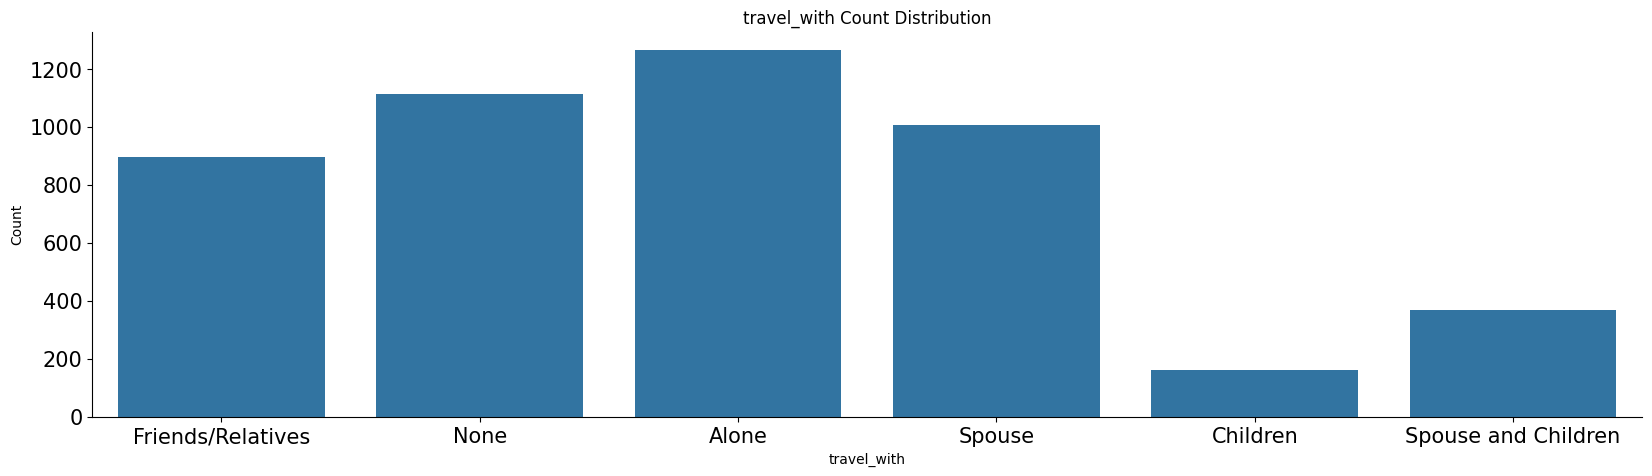

In [45]:
fig, ax = plt.subplots()
fig.set_size_inches(20, 5)
sns.countplot(x = 'travel_with', data = train_df)
ax.set_xlabel('travel_with')
ax.set_ylabel('Count')
ax.set_title('travel_with Count Distribution')
ax.tick_params(labelsize=15)
sns.despine()

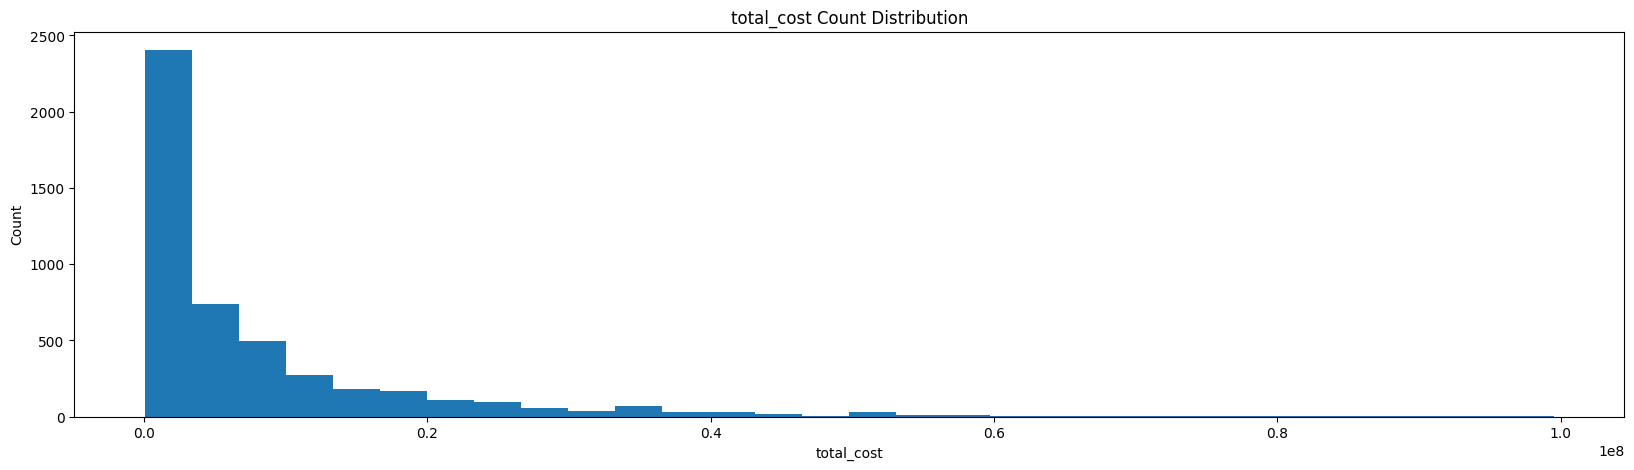

In [46]:
plt.figure(figsize=(20,5))
plt.hist(train_df['total_cost'], bins=30)
plt.xlabel('total_cost')
plt.ylabel('Count')
plt.title('total_cost Count Distribution')
plt.show()

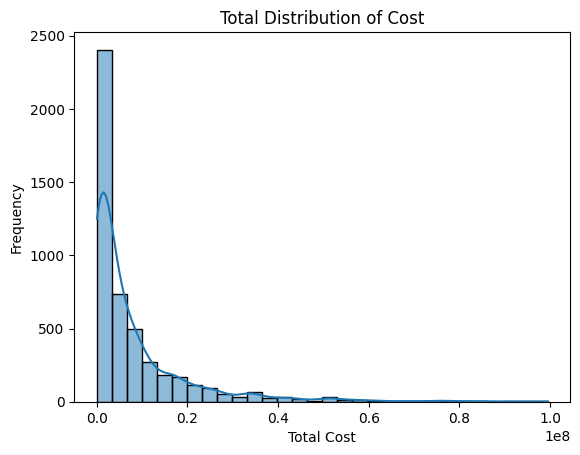

In [47]:
sns.histplot(train_df['total_cost'], kde=True, bins =30)
plt.title('Total Distribution of Cost')
plt.xlabel('Total Cost')
plt.ylabel('Frequency')
plt.show()

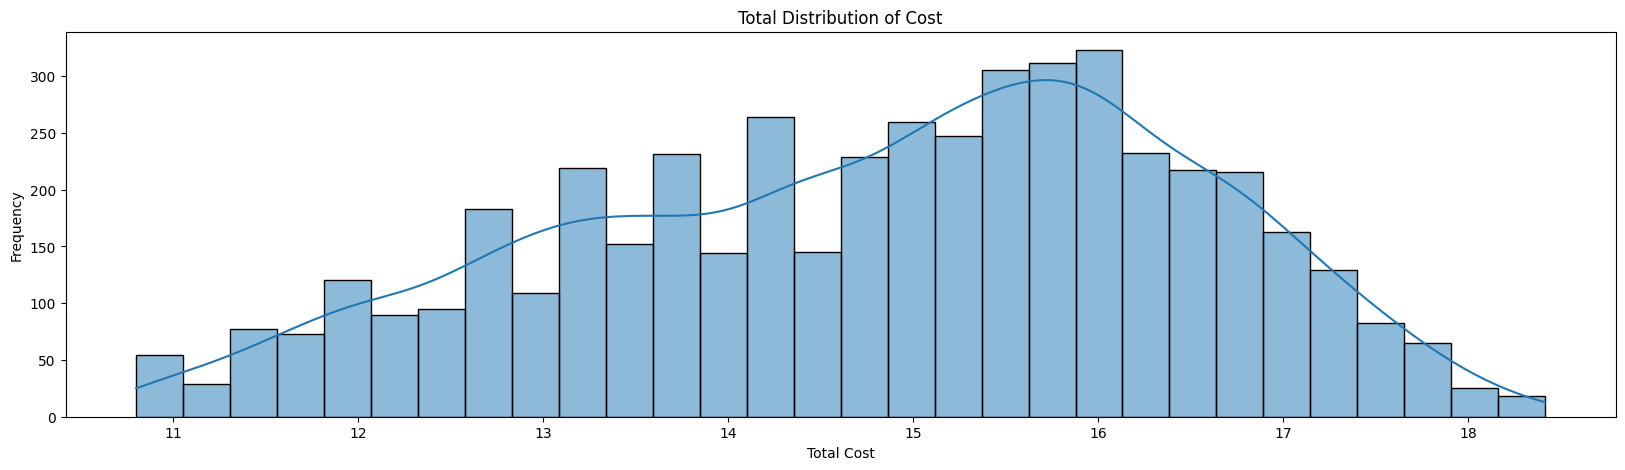

In [48]:
import numpy as np
train_df['total_cost_log'] = np.log1p(train_df['total_cost'])
# Now plot this new column—it should look much more like a bell curve!
plt.figure(figsize=(20,5))
sns.histplot(train_df['total_cost_log'], kde=True, bins =30)
plt.xlabel('Total Cost')
plt.ylabel('Frequency')
plt.title('Total Distribution of Cost')
plt.show()

In [49]:
train_df.select_dtypes(include=['category']).columns

Index([], dtype='object')

In [50]:
train_df.shape

(4809, 24)

In [51]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4809 non-null   object 
 1   country                4809 non-null   object 
 2   age_group              4809 non-null   object 
 3   travel_with            4809 non-null   object 
 4   total_female           4809 non-null   float64
 5   total_male             4809 non-null   float64
 6   purpose                4809 non-null   object 
 7   main_activity          4809 non-null   object 
 8   info_source            4809 non-null   object 
 9   tour_arrangement       4809 non-null   object 
 10  package_transport_int  4809 non-null   object 
 11  package_accomodation   4809 non-null   object 
 12  package_food           4809 non-null   object 
 13  package_transport_tz   4809 non-null   object 
 14  package_sightseeing    4809 non-null   object 
 15  pack

In [52]:
#label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train_df['first_trip_tz'] = le.fit_transform(train_df['first_trip_tz'])
train_df['first_trip_tz'].unique()

array([0, 1])

In [53]:
train_df['package_transport_int'] = le.fit_transform(train_df['package_transport_int'])
train_df['package_transport_int'].unique()

array([0, 1])

In [54]:
#one hot encoding
columns_to_transform = ['travel_with', 'most_impressing']
train_df = pd.get_dummies(train_df, columns=  columns_to_transform)
train_df.head()




,ID,country,age_group,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,...,travel_with_Spouse,travel_with_Spouse and Children,most_impressing_ Wildlife,most_impressing_Excellent Experience,most_impressing_Friendly People,most_impressing_Good service,most_impressing_No comments,most_impressing_None,most_impressing_Satisfies and Hope Come Back,"most_impressing_Wonderful Country, Landscape, Nature"
0,tour_0,SWIZERLAND,45-64,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,0,...,False,False,False,False,True,False,False,False,False,False
1,tour_10,UNITED KINGDOM,25-44,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,0,...,False,False,False,False,False,False,False,False,False,True
2,tour_1000,UNITED KINGDOM,25-44,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,0,...,False,False,False,True,False,False,False,False,False,False
3,tour_1002,UNITED KINGDOM,25-44,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,0,...,True,False,False,False,True,False,False,False,False,False
4,tour_1004,CHINA,1-24,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,0,...,False,False,False,False,False,False,True,False,False,False


In [56]:
train_df.shape

(4809, 37)

In [55]:
#creation of new features
train_df['total_people'] = train_df['total_female'] + train_df['total_male']
train_df['total_people']

,total_people
0,2.0
1,1.0
2,1.0
3,2.0
4,1.0
...,...
4804,1.0
4805,2.0
4806,1.0
4807,2.0


In [58]:
train_df.shape


(4809, 37)

In [59]:
age_map = {'1-24':1, '24-44':2, '45-64':3,'65+':4}
train_df['age_group'] = train_df['age_group'].map(age_map)
train_df= train_df.drop('age_group', axis=1)
train_df.head()

,ID,country,total_female,total_male,purpose,main_activity,info_source,tour_arrangement,package_transport_int,package_accomodation,...,travel_with_Spouse and Children,most_impressing_ Wildlife,most_impressing_Excellent Experience,most_impressing_Friendly People,most_impressing_Good service,most_impressing_No comments,most_impressing_None,most_impressing_Satisfies and Hope Come Back,"most_impressing_Wonderful Country, Landscape, Nature",total_people
0,tour_0,SWIZERLAND,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Friends, relatives",Independent,0,No,...,False,False,False,True,False,False,False,False,False,2.0
1,tour_10,UNITED KINGDOM,1.0,0.0,Leisure and Holidays,Cultural tourism,others,Independent,0,No,...,False,False,False,False,False,False,False,False,True,1.0
2,tour_1000,UNITED KINGDOM,0.0,1.0,Visiting Friends and Relatives,Cultural tourism,"Friends, relatives",Independent,0,No,...,False,False,True,False,False,False,False,False,False,1.0
3,tour_1002,UNITED KINGDOM,1.0,1.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Package Tour,0,Yes,...,False,False,False,True,False,False,False,False,False,2.0
4,tour_1004,CHINA,1.0,0.0,Leisure and Holidays,Wildlife tourism,"Travel, agent, tour operator",Independent,0,No,...,False,False,False,False,False,True,False,False,False,1.0


In [60]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4809 entries, 0 to 4808
Data columns (total 36 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   ID                                                    4809 non-null   object 
 1   country                                               4809 non-null   object 
 2   total_female                                          4809 non-null   float64
 3   total_male                                            4809 non-null   float64
 4   purpose                                               4809 non-null   object 
 5   main_activity                                         4809 non-null   object 
 6   info_source                                           4809 non-null   object 
 7   tour_arrangement                                      4809 non-null   object 
 8   package_transport_int                                 4809